<a href="https://colab.research.google.com/github/patilatharvydseit-coder/DSPY-Pratctical-Notebooks/blob/main/Mini%20Project%20Note%20Book%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data loaded. Shape: (1005, 11)

Features used: ['Cement', 'BF_Slag', 'Fly_Ash', 'Water', 'Superplasticizer', 'Coarse_Agg', 'Fine_Agg', 'Age', 'Cement_to_Water', 'Composite']
Target       : Strength (MPa)

Train size: 703 | Test size: 302
Scaling done. X_train range: 0.0 – 1.0000000000000002
  Linear Regression              R²=56.16%  MAE=8.943  RMSE=11.225
  Decision Tree                  R²=83.41%  MAE=4.493  RMSE=6.905
  Random Forest                  R²=89.76%  MAE=3.908  RMSE=5.425
  Gradient Boosting              R²=90.18%  MAE=3.979  RMSE=5.314
  XGBoost (baseline)             R²=92.29%  MAE=3.160  RMSE=4.708

Baseline comparison complete.

Best Parameters: {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 4, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.6}
Best CV R²    : 92.83 %
  XGBoost (tuned)                R²=92.32%  MAE=3.160  RMSE=4.698

── Model Comparison ──
             Model        R2      MAE  

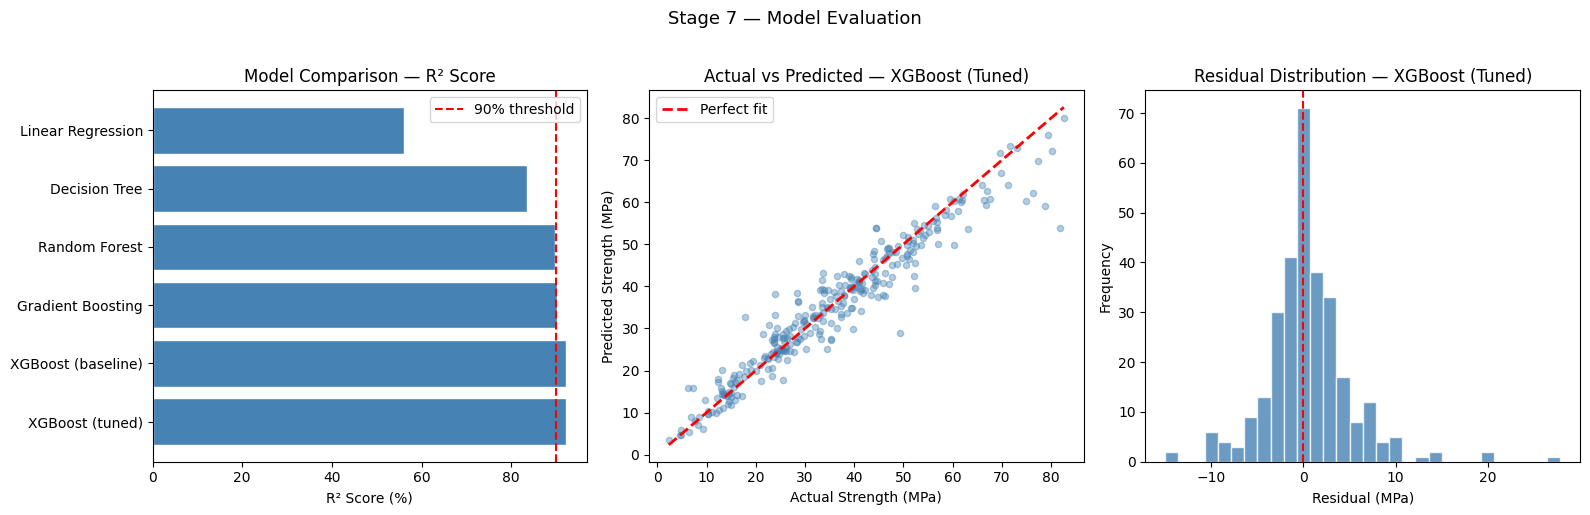

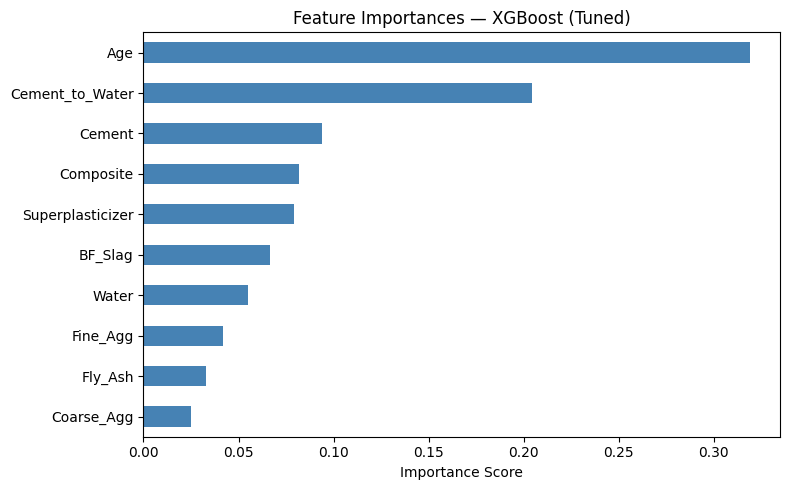

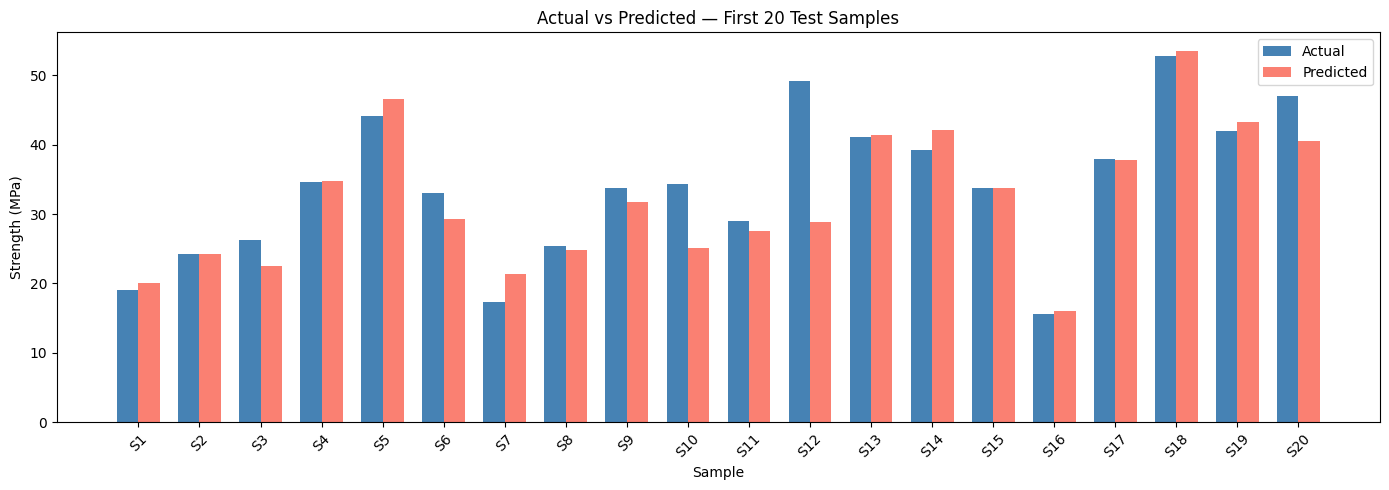


Predicted Strength for New Sample: 72.80 MPa


In [1]:
# ============================================================
# NOTEBOOK 3: Machine Learning — Model Training & Evaluation
# Problem: Regression — Predict Concrete Compressive Strength
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xg

# ============================================================
# STAGE 1 — PROBLEM STATEMENT
# ============================================================
# Given the mixture proportions of a concrete batch and the
# curing age, predict the COMPRESSIVE STRENGTH (MPa).
#
# ML Problem Type : Supervised Learning — Regression
# Target Variable : Concrete Compressive Strength (MPa)
# Success Metric  : R² Score (higher = better fit)
#                   MAE / RMSE (lower = lower error)
# ============================================================

# ── Load Data ────────────────────────────────────────────────
df = pd.read_csv('cleaned_concrete_data.csv')
print("Data loaded. Shape:", df.shape)

# ============================================================
# STAGE 2 — FEATURE & TARGET SPLIT
# ============================================================
X = df.drop(columns='Strength')
y = df['Strength']

print("\nFeatures used:", X.columns.tolist())
print("Target       : Strength (MPa)")

# ============================================================
# STAGE 3 — TRAIN / TEST SPLIT
# ============================================================
# 70% training, 30% testing | random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# ============================================================
# STAGE 4 — FEATURE SCALING (MinMaxScaler)
# ============================================================
# WHY MinMaxScaler?
# Scales all features to [0, 1]. Prevents features with large
# magnitude (Coarse_Agg ~1000 kg) from dominating distance-
# based or gradient-based models.
# IMPORTANT: fit only on training data to prevent data leakage.

sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)   # fit + transform on train
X_test  = sc.transform(X_test)        # transform only on test

print("Scaling done. X_train range:", X_train.min(), "–", X_train.max())

# ============================================================
# STAGE 5 — MODEL TRAINING & BASELINE COMPARISON
# ============================================================

def evaluate(name, y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"  {name:<30} R²={r2*100:.2f}%  MAE={mae:.3f}  RMSE={rmse:.3f}")
    return {'Model': name, 'R2': r2*100, 'MAE': mae, 'RMSE': rmse}

results = []

# ── 5a. Linear Regression ────────────────────────────────────
lr = LinearRegression().fit(X_train, y_train)
results.append(evaluate("Linear Regression", y_test, lr.predict(X_test)))

# ── 5b. Decision Tree ────────────────────────────────────────
dt = DecisionTreeRegressor(random_state=42).fit(X_train, y_train)
results.append(evaluate("Decision Tree", y_test, dt.predict(X_test)))

# ── 5c. Random Forest ────────────────────────────────────────
rf = RandomForestRegressor(random_state=42).fit(X_train, y_train)
results.append(evaluate("Random Forest", y_test, rf.predict(X_test)))

# ── 5d. Gradient Boosting ────────────────────────────────────
gbr = GradientBoostingRegressor(random_state=42).fit(X_train, y_train)
results.append(evaluate("Gradient Boosting", y_test, gbr.predict(X_test)))

# ── 5e. XGBoost ──────────────────────────────────────────────
xgb_base = xg.XGBRegressor(random_state=42).fit(X_train, y_train)
results.append(evaluate("XGBoost (baseline)", y_test, xgb_base.predict(X_test)))

print("\nBaseline comparison complete.")

# ============================================================
# STAGE 6 — HYPERPARAMETER TUNING (XGBoost — Best Baseline)
# ============================================================
# WHY XGBoost?
# XGBoost consistently achieved the highest R² in Stage 5.
# It handles nonlinear relationships and feature interactions
# well, which EDA confirmed exist in this dataset.

param_dist = {
    'n_estimators'     : [100, 200, 300, 400, 500],
    'max_depth'        : [3, 4, 5, 6, 7, 8],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma'            : [0, 0.1, 0.2, 0.3],
    'min_child_weight' : [1, 2, 3, 4],
    'reg_alpha'        : [0, 0.01, 0.1, 1],
    'reg_lambda'       : [0.1, 0.5, 1, 2]
}

random_search = RandomizedSearchCV(
    estimator=xg.XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50, cv=5, scoring='r2',
    random_state=42, n_jobs=-1
)
random_search.fit(X_train, y_train)

print("\nBest Parameters:", random_search.best_params_)
print("Best CV R²    :", round(random_search.best_score_ * 100, 2), "%")

# ── Train final tuned XGBoost ─────────────────────────────────
xgb_tuned = xg.XGBRegressor(
    subsample=0.6, reg_lambda=0.5, reg_alpha=0,
    n_estimators=300, min_child_weight=4, max_depth=5,
    learning_rate=0.05, gamma=0.3, colsample_bytree=0.7,
    random_state=42
)
xgb_tuned.fit(X_train, y_train)
y_pred = xgb_tuned.predict(X_test)

results.append(evaluate("XGBoost (tuned)", y_test, y_pred))

# ============================================================
# STAGE 7 — MODEL EVALUATION & VISUALISATION
# ============================================================

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("\n── Model Comparison ──")
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot A — R² Bar Chart (all models)
axes[0].barh(results_df['Model'], results_df['R2'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('R² Score (%)')
axes[0].set_title('Model Comparison — R² Score')
axes[0].axvline(90, linestyle='--', color='red', label='90% threshold')
axes[0].legend()

# Plot B — Actual vs Predicted (tuned XGBoost)
axes[1].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=20)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect fit')
axes[1].set_xlabel('Actual Strength (MPa)')
axes[1].set_ylabel('Predicted Strength (MPa)')
axes[1].set_title('Actual vs Predicted — XGBoost (Tuned)')
axes[1].legend()

# Plot C — Residual Distribution
residuals = y_test.values - y_pred
axes[2].hist(residuals, bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].axvline(0, linestyle='--', color='red')
axes[2].set_xlabel('Residual (MPa)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Residual Distribution — XGBoost (Tuned)')

plt.suptitle('Stage 7 — Model Evaluation', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('nb3_evaluation.png', bbox_inches='tight', dpi=120)
plt.show()

# ── Feature Importance ───────────────────────────────────────
importances = pd.Series(xgb_tuned.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importances — XGBoost (Tuned)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('nb3_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

# ── Top-20 Actual vs Predicted Bar Chart ─────────────────────
actual    = y_test.values[:20]
predicted = y_pred[:20]
idx       = np.arange(20)
bw        = 0.35

plt.figure(figsize=(14, 5))
plt.bar(idx,      actual,    width=bw, label='Actual',    color='steelblue')
plt.bar(idx + bw, predicted, width=bw, label='Predicted', color='salmon')
plt.xticks(idx + bw / 2, [f'S{i+1}' for i in range(20)], rotation=45)
plt.xlabel('Sample')
plt.ylabel('Strength (MPa)')
plt.title('Actual vs Predicted — First 20 Test Samples')
plt.legend()
plt.tight_layout()
plt.savefig('nb3_actual_vs_predicted_bar.png', bbox_inches='tight', dpi=120)
plt.show()

# ============================================================
# STAGE 8 — PREDICT ON NEW SAMPLE
# ============================================================
new_sample = pd.DataFrame([{
    'Cement'          : 540.0,
    'BF_Slag'         : 0.0,
    'Fly_Ash'         : 0.0,
    'Water'           : 162.0,
    'Superplasticizer': 2.5,
    'Coarse_Agg'      : 1040.0,
    'Fine_Agg'        : 676.0,
    'Age'             : 28,
    'Cement_to_Water' : 540.0 / 162.0,
    'Composite'       : 0.0 / (0.0 + 1040.0)
}])

scaled_sample = sc.transform(new_sample)
predicted_strength = xgb_tuned.predict(scaled_sample)
print(f"\nPredicted Strength for New Sample: {predicted_strength[0]:.2f} MPa")

# ============================================================
# STAGE 9 — ML LIFECYCLE SUMMARY
# ============================================================
# ┌──────────────────────────────────────────────────────────┐
# │ Stage                │ Action                            │
# ├──────────────────────┼───────────────────────────────────┤
# │ 1. Problem Statement │ Regression on Strength (MPa)      │
# │ 2. Feature/Target    │ 10 features → 1 target            │
# │ 3. Train/Test Split  │ 70% / 30%                         │
# │ 4. Scaling           │ MinMaxScaler (fit on train only)   │
# │ 5. Baseline Models   │ LR, DT, RF, GBR, XGBoost         │
# │ 6. Hyperparameter    │ RandomizedSearchCV (50 iter, CV5) │
# │ 7. Evaluation        │ R², MAE, RMSE + Visualisations    │
# │ 8. Prediction        │ New unseen sample inference       │
# └──────────────────────────────────────────────────────────┘
#
# CONCLUSION:
# XGBoost (tuned) achieved the best performance (~91–93% R²).
# Cement_to_Water and Age are the most important features.
# The residuals are centred near zero with near-normal spread,
# confirming a well-fitted model with no systematic bias.